<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/TensorFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1

In [1]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# ============================================
# PROBLEM 1: Review of Fundamentals
# ============================================

print("="*60)
print("PROBLEM 1: Deep Learning Fundamentals")
print("="*60)

# 1. DATA PREPARATION
print("\n1. DATA PREPARATION")
iris = load_iris()
mask = iris.target != 0
X = iris.data[mask].astype(np.float32)
y = (iris.target[mask] == 2).astype(np.float32).reshape(-1, 1)

# Split into train, validation, test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train,
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# 2. DATA PREPROCESSING
print("\n2. DATA PREPROCESSING")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
print("Features standardized to mean=0, std=1")

# 3. HYPERPARAMETERS
print("\n3. HYPERPARAMETERS (Developer Decisions)")
learning_rate = 0.001
batch_size = 10
num_epochs = 100
n_hidden1 = 50
n_hidden2 = 100
n_input = X_train.shape[1]
n_classes = 1

print(f"Learning rate: {learning_rate}")
print(f"Batch size: {batch_size}")
print(f"Number of epochs: {num_epochs}")
print(f"Hidden layer 1: {n_hidden1} neurons")
print(f"Hidden layer 2: {n_hidden2} neurons")

# 4. DATASET CREATION
print("\n4. DATASET CREATION (Mini-batch preparation)")
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=0, reshuffle_each_iteration=True)
    .batch(batch_size)
)
print(f"Training dataset created with {batch_size} samples per batch")

# 5. MODEL DEFINITION
print("\n5. MODEL DEFINITION (Architecture Design)")
class ThreeLayerNetwork(tf.Module):
    """Three-layer network implemented with TensorFlow operations."""

    def __init__(self, n_input, n_hidden1, n_hidden2, n_classes, seed=0):
        super().__init__()
        generator = tf.random.Generator.from_seed(seed)

        # WEIGHT & BIAS INITIALIZATION
        print("   - Initializing weights with normal distribution (std=0.1)")
        self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=0.1))
        print(f"     w1 shape: {self.w1.shape}")
        self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
        print(f"     b1 shape: {self.b1.shape}")

        self.w2 = tf.Variable(generator.normal((n_hidden1, n_hidden2), stddev=0.1))
        print(f"     w2 shape: {self.w2.shape}")
        self.b2 = tf.Variable(tf.zeros((n_hidden2,)))
        print(f"     b2 shape: {self.b2.shape}")

        self.w3 = tf.Variable(generator.normal((n_hidden2, n_classes), stddev=0.1))
        print(f"     w3 shape: {self.w3.shape}")
        self.b3 = tf.Variable(tf.zeros((n_classes,)))
        print(f"     b3 shape: {self.b3.shape}")

    def __call__(self, x):
        # FORWARD PROPAGATION
        print("   - Forward propagation:")
        print(f"     Input shape: {x.shape}")

        # Layer 1: Linear + ReLU
        layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        print(f"     Layer 1 output shape: {layer_1.shape}")

        # Layer 2: Linear + ReLU
        layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
        print(f"     Layer 2 output shape: {layer_2.shape}")

        # Output layer: Linear (no activation for binary classification with logits)
        output = tf.matmul(layer_2, self.w3) + self.b3
        print(f"     Output shape: {output.shape}")
        return output

model = ThreeLayerNetwork(n_input, n_hidden1, n_hidden2, n_classes)

# 6. LOSS FUNCTION
print("\n6. LOSS FUNCTION")
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
print("Binary Cross-entropy loss (from_logits=True)")

# 7. OPTIMIZER
print("\n7. OPTIMIZER")
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
print(f"Adam optimizer with learning_rate={learning_rate}")

# 8. METRICS
print("\n8. METRICS")
def accuracy_fn(y_true, logits):
    predictions = tf.cast(tf.sigmoid(logits) >= 0.5, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, predictions), tf.float32))
print("Binary accuracy metric defined")

# 9. TRAINING STEP (Forward, Loss, Backprop, Update)
print("\n9. TRAINING STEP (All in one function)")
def train_step(X_batch, y_batch):
    # FORWARD PROPAGATION + LOSS CALCULATION
    with tf.GradientTape() as tape:
        logits = model(X_batch)
        loss = loss_fn(y_batch, logits)

    # BACKPROPAGATION - Gradient Calculation
    gradients = tape.gradient(loss, model.trainable_variables)
    print(f"   - Gradients computed for {len(gradients)} variables")

    # PARAMETER UPDATE
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    print("   - Parameters updated using Adam optimizer")

    return loss, accuracy_fn(y_batch, logits)

print("Train step function defined with:")
print("   - Forward propagation")
print("   - Loss calculation")
print("   - Gradient computation (automatic differentiation)")
print("   - Parameter updates")

# 10. TRAINING LOOP
print("\n10. TRAINING LOOP (Epoch and Mini-batch iterations)")
print(f"Training for {num_epochs} epochs with mini-batches")

for epoch in range(num_epochs):
    train_losses = []
    for X_batch, y_batch in train_dataset:
        loss, _ = train_step(X_batch, y_batch)
        train_losses.append(float(loss))

    # VALIDATION
    val_logits = model(X_val)
    val_loss = float(loss_fn(y_val, val_logits))
    val_accuracy = float(accuracy_fn(y_val, val_logits))

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"   Epoch {epoch:3d}, loss: {np.mean(train_losses):.4f}, "
              f"val_loss: {val_loss:.4f}, val_acc: {val_accuracy:.3f}")

# 11. EVALUATION
print("\n11. EVALUATION (Test set)")
test_logits = model(X_test)
test_accuracy = float(accuracy_fn(y_test, test_logits))
print(f"Test Accuracy: {test_accuracy:.3f}")

print("\n" + "="*60)
print("SUMMARY: Deep Learning Steps vs TensorFlow Automation")
print("="*60)

summary = {
    "Step": [
        "1. Data Preparation",
        "2. Data Preprocessing",
        "3. Model Architecture",
        "4. Weight Initialization",
        "5. Forward Propagation",
        "6. Loss Calculation",
        "7. Backpropagation (Gradients)",
        "8. Parameter Updates",
        "9. Mini-batch Processing",
        "10. Epoch Loop",
        "11. Validation",
        "12. Testing"
    ],
    "Developer Decision": [
        "How to split data",
        "Choice of scaler (StandardScaler)",
        "Number of layers and neurons",
        "Initialization method (std=0.1)",
        "Layer design (ReLU activations)",
        "Which loss function to use",
        "None - automated by TensorFlow",
        "Which optimizer and learning rate",
        "Batch size selection",
        "Number of epochs",
        "Validation frequency",
        "Which metrics to report"
    ],
    "TensorFlow Automation": [
        "Dataset creation API (from_tensor_slices)",
        "Transform operations (fit_transform)",
        "Module class structure",
        "Generator for random initialization",
        "Matmul, relu operations",
        "BinaryCrossentropy implementation",
        "GradientTape automatic differentiation",
        "Adam optimizer update rules",
        "Dataset.shuffle and .batch",
        "Loop iteration",
        "Model forward pass",
        "Metrics calculation"
    ]
}

for i in range(len(summary["Step"])):
    print(f"\n{summary['Step'][i]}:")
    print(f"  Developer: {summary['Developer Decision'][i]}")
    print(f"  TensorFlow: {summary['TensorFlow Automation'][i]}")

Streaming output truncated to the last 5000 lines.
   - Gradients computed for 6 variables
   - Parameters updated using Adam optimizer
   - Forward propagation:
     Input shape: (10, 4)
     Layer 1 output shape: (10, 50)
     Layer 2 output shape: (10, 100)
     Output shape: (10, 1)
   - Gradients computed for 6 variables
   - Parameters updated using Adam optimizer
   - Forward propagation:
     Input shape: (4, 4)
     Layer 1 output shape: (4, 50)
     Layer 2 output shape: (4, 100)
     Output shape: (4, 1)
   - Gradients computed for 6 variables
   - Parameters updated using Adam optimizer
   - Forward propagation:
     Input shape: (16, 4)
     Layer 1 output shape: (16, 50)
     Layer 2 output shape: (16, 100)
     Output shape: (16, 1)
   - Forward propagation:
     Input shape: (10, 4)
     Layer 1 output shape: (10, 50)
     Layer 2 output shape: (10, 100)
     Output shape: (10, 1)
   - Gradients computed for 6 variables
   - Parameters updated using Adam optimizer
   - 

In [ ]:
## Problem 2

In [2]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# ============================================
# PROBLEM 2: Scratch vs TensorFlow Correspondence
# ============================================

print("="*70)
print("PROBLEM 2: Scratch Implementation vs TensorFlow Correspondence")
print("="*70)

# Load data
iris = load_iris()
mask = iris.target != 0
X = iris.data[mask].astype(np.float32)
y = (iris.target[mask] == 2).astype(np.float32).reshape(-1, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train,
)

# Preprocess
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# Hyperparameters
learning_rate = 0.001
batch_size = 10
num_epochs = 100
n_hidden1 = 50
n_hidden2 = 100
n_input = X_train.shape[1]
n_classes = 1

# Create dataset
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=0, reshuffle_each_iteration=True)
    .batch(batch_size)
)

# Model class
class ThreeLayerNetwork(tf.Module):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_classes, seed=0):
        super().__init__()
        generator = tf.random.Generator.from_seed(seed)
        self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=0.1))
        self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
        self.w2 = tf.Variable(generator.normal((n_hidden1, n_hidden2), stddev=0.1))
        self.b2 = tf.Variable(tf.zeros((n_hidden2,)))
        self.w3 = tf.Variable(generator.normal((n_hidden2, n_classes), stddev=0.1))
        self.b3 = tf.Variable(tf.zeros((n_classes,)))

    def __call__(self, x):
        layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
        return tf.matmul(layer_2, self.w3) + self.b3

model = ThreeLayerNetwork(n_input, n_hidden1, n_hidden2, n_classes)
loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

def accuracy_fn(y_true, logits):
    predictions = tf.cast(tf.sigmoid(logits) >= 0.5, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, predictions), tf.float32))

def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = model(X_batch)
        loss = loss_fn(y_batch, logits)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, accuracy_fn(y_batch, logits)

print("\n" + "="*70)
print("DETAILED CORRESPONDENCE TABLE")
print("="*70)

correspondence = [
    {
        "Scratch Step": "1. Initialize weights and biases",
        "Scratch Code": """
for i in range(layers):
    W[i] = np.random.randn(...) * 0.1
    b[i] = np.zeros(...)""",
        "TensorFlow Code": "Lines 51-56",
        "TensorFlow Implementation": """
generator = tf.random.Generator.from_seed(seed)
self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=0.1))
self.b1 = tf.Variable(tf.zeros((n_hidden1,)))""",
        "Key TF Feature": "tf.Variable, tf.random.Generator",
        "Automation": "Random generation with seed control"
    },
    {
        "Scratch Step": "2. Forward propagation",
        "Scratch Code": """
for i in range(layers):
    z[i] = np.dot(A[i-1], W[i]) + b[i]
    A[i] = relu(z[i])""",
        "TensorFlow Code": "Lines 58-61",
        "TensorFlow Implementation": """
layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
return tf.matmul(layer_2, self.w3) + self.b3""",
        "Key TF Feature": "tf.matmul, tf.nn.relu",
        "Automation": "Efficient matrix operations, GPU acceleration"
    },
    {
        "Scratch Step": "3. Calculate loss",
        "Scratch Code": """
loss = -np.mean(y_true * np.log(p) + (1-y_true) * np.log(1-p))""",
        "TensorFlow Code": "Line 69",
        "TensorFlow Implementation": "loss_fn = tf.keras.losses.BinaryCrossentropy(from_logits=True)",
        "Key TF Feature": "tf.keras.losses",
        "Automation": "Numerically stable implementation"
    },
    {
        "Scratch Step": "4. Backpropagation (gradients)",
        "Scratch Code": """
for i in reversed(range(layers)):
    dW[i] = np.dot(A[i-1].T, delta[i])
    db[i] = np.sum(delta[i], axis=0, keepdims=True)""",
        "TensorFlow Code": "Lines 84-86",
        "TensorFlow Implementation": """
with tf.GradientTape() as tape:
    logits = model(X_batch)
    loss = loss_fn(y_batch, logits)
gradients = tape.gradient(loss, model.trainable_variables)""",
        "Key TF Feature": "tf.GradientTape",
        "Automation": "Automatic differentiation, chain rule"
    },
    {
        "Scratch Step": "5. Update parameters",
        "Scratch Code": """
for i in range(layers):
    W[i] -= learning_rate * dW[i]
    b[i] -= learning_rate * db[i]""",
        "TensorFlow Code": "Line 87",
        "TensorFlow Implementation": "optimizer.apply_gradients(zip(gradients, model.trainable_variables))",
        "Key TF Feature": "tf.keras.optimizers",
        "Automation": "Optimization algorithms (Adam, SGD, etc.)"
    },
    {
        "Scratch Step": "6. Epoch and mini-batch loops",
        "Scratch Code": """
for epoch in range(num_epochs):
    for i in range(0, len(X), batch_size):
        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]
        # training step""",
        "TensorFlow Code": "Lines 44-47, 93-94",
        "TensorFlow Implementation": """
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(...).batch(batch_size)
for epoch in range(num_epochs):
    for X_batch, y_batch in train_dataset:""",
        "Key TF Feature": "tf.data.Dataset",
        "Automation": "Data pipelining, prefetching, shuffling"
    },
    {
        "Scratch Step": "7. Validation",
        "Scratch Code": """
val_logits = forward_prop(X_val)
val_loss = calculate_loss(y_val, val_logits)
val_acc = calculate_accuracy(y_val, val_logits)""",
        "TensorFlow Code": "Lines 96-99",
        "TensorFlow Implementation": """
val_logits = model(X_val)
val_loss = float(loss_fn(y_val, val_logits))
val_accuracy = float(accuracy_fn(y_val, val_logits))""",
        "Key TF Feature": "Model inference, metrics",
        "Automation": "Efficient evaluation on batches"
    },
    {
        "Scratch Step": "8. Test evaluation",
        "Scratch Code": """
test_logits = forward_prop(X_test)
test_acc = calculate_accuracy(y_test, test_logits)""",
        "TensorFlow Code": "Lines 108-109",
        "TensorFlow Implementation": """
test_logits = model(X_test)
test_accuracy = float(accuracy_fn(y_test, test_logits))""",
        "Key TF Feature": "Model inference",
        "Automation": "Final evaluation"
    }
]

for i, item in enumerate(correspondence, 1):
    print(f"\n{i}. {item['Scratch Step']}")
    print(f"   {'-'*60}")
    print(f"   Scratch Implementation:")
    print(f"   {item['Scratch Code']}")
    print(f"\n   TensorFlow Implementation:")
    print(f"   {item['TensorFlow Implementation']}")
    print(f"   (Code lines: {item['TensorFlow Code']})")
    print(f"\n   Key TensorFlow Feature: {item['Key TF Feature']}")
    print(f"   What TensorFlow Automates: {item['Automation']}")

print("\n" + "="*70)
print("SUMMARY: TensorFlow vs Scratch Implementation")
print("="*70)

print("""
SCRATCH IMPLEMENTATION (Manual):
- You write every mathematical operation
- You manually compute gradients using chain rule
- You explicitly loop through each sample
- You update each weight individually
- You handle all numerical stability issues
- Code is longer and more error-prone
- Harder to scale to GPUs

TENSORFLOW IMPLEMENTATION (Automated):
- Higher-level operations (matmul, relu)
- Automatic differentiation with GradientTape
- Optimized data pipeline with tf.data
- Optimizer handles parameter updates
- Built-in numerical stability
- Code is concise and maintainable
- Automatic GPU/TPU acceleration
- Better for production and research

KEY TENSORFLOW FEATURES USED:
1. tf.Variable: Trainable parameters
2. tf.GradientTape: Automatic differentiation
3. tf.keras.losses: Pre-built loss functions
4. tf.keras.optimizers: Optimization algorithms
5. tf.data.Dataset: Data pipeline
6. tf.random: Controlled random generation
7. tf.nn: Neural network operations
8. TensorFlow's eager execution: Immediate evaluation

NOTES ON GRADIENTTAPE:
- Records operations for automatic differentiation
- Context manager: 'with tf.GradientTape() as tape:'
- Computes gradients using reverse-mode autodiff
- Handles complex computational graphs
- Supports higher-order gradients
- Can be used with custom training loops
- Provides fine-grained control over training
""")

print("\nDocumentation Reference: https://www.tensorflow.org/api_docs/python/tf/GradientTape")

PROBLEM 2: Scratch Implementation vs TensorFlow Correspondence

DETAILED CORRESPONDENCE TABLE

1. 1. Initialize weights and biases
   ------------------------------------------------------------
   Scratch Implementation:
   
for i in range(layers):
    W[i] = np.random.randn(...) * 0.1
    b[i] = np.zeros(...)

   TensorFlow Implementation:
   
generator = tf.random.Generator.from_seed(seed)
self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=0.1))
self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
   (Code lines: Lines 51-56)

   Key TensorFlow Feature: tf.Variable, tf.random.Generator
   What TensorFlow Automates: Random generation with seed control

2. 2. Forward propagation
   ------------------------------------------------------------
   Scratch Implementation:
   
for i in range(layers):
    z[i] = np.dot(A[i-1], W[i]) + b[i]
    A[i] = relu(z[i])

   TensorFlow Implementation:
   
layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
layer_2 = tf.nn.relu(tf.matmul(l

In [ ]:
## Problem 3

In [3]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# ============================================
# PROBLEM 3: Iris Multiclass Classification
# ============================================

# Load data
iris = load_iris()
X = iris.data.astype(np.float32)
y = iris.target  # Keep as integers (0, 1, 2)

# Split into train, validation, test (80/10/10)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0, stratify=y_train
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Preprocess only training data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# Create dataset
batch_size = 16
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(len(X_train), seed=0, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size)

# Define model
class MulticlassNetwork(tf.Module):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_classes, seed=0):
        super().__init__()
        generator = tf.random.Generator.from_seed(seed)
        # He initialization for better performance
        self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=np.sqrt(2.0/n_input)))
        self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
        self.w2 = tf.Variable(generator.normal((n_hidden1, n_hidden2), stddev=np.sqrt(2.0/n_hidden1)))
        self.b2 = tf.Variable(tf.zeros((n_hidden2,)))
        self.w3 = tf.Variable(generator.normal((n_hidden2, n_classes), stddev=np.sqrt(2.0/n_hidden2)))
        self.b3 = tf.Variable(tf.zeros((n_classes,)))

    def __call__(self, x):
        layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
        return tf.matmul(layer_2, self.w3) + self.b3  # No softmax, use from_logits=True

# Hyperparameters
learning_rate = 0.01
n_hidden1 = 64
n_hidden2 = 32
n_input = X_train.shape[1]
n_classes = 3
num_epochs = 200

# Initialize model, loss, optimizer
model = MulticlassNetwork(n_input, n_hidden1, n_hidden2, n_classes)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Accuracy function for multiclass
def accuracy_fn(y_true, logits):
    predictions = tf.argmax(logits, axis=1)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, predictions), tf.float32))

# Training step
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        logits = model(X_batch)
        loss = loss_fn(y_batch, logits)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, accuracy_fn(y_batch, logits)

# Train
print("\nTraining Iris Multiclass Model...")
best_val_acc = 0
for epoch in range(num_epochs):
    train_losses = []
    train_accuracies = []
    for X_batch, y_batch in train_dataset:
        loss, acc = train_step(X_batch, y_batch)
        train_losses.append(float(loss))
        train_accuracies.append(float(acc))

    # Validation
    val_logits = model(X_val)
    val_loss = float(loss_fn(y_val, val_logits))
    val_accuracy = float(accuracy_fn(y_val, val_logits))

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        best_weights = [w.numpy() for w in model.trainable_variables]

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d}, loss: {np.mean(train_losses):.4f}, "
              f"train_acc: {np.mean(train_accuracies):.3f}, "
              f"val_loss: {val_loss:.4f}, val_acc: {val_accuracy:.3f}")

# Restore best weights
for var, weight in zip(model.trainable_variables, best_weights):
    var.assign(weight)

# Test
test_logits = model(X_test)
test_accuracy = float(accuracy_fn(y_test, test_logits))
print(f"\nTest accuracy: {test_accuracy:.3f}")

# Show class predictions
predictions = tf.argmax(test_logits, axis=1)
print(f"Predictions: {predictions.numpy()}")
print(f"True labels:  {y_test}")

Train: (96, 4), Val: (24, 4), Test: (30, 4)

Training Iris Multiclass Model...
Epoch   0, loss: 0.7128, train_acc: 0.698, val_loss: 0.1693, val_acc: 0.917
Epoch  20, loss: 0.0688, train_acc: 0.979, val_loss: 0.0783, val_acc: 0.958
Epoch  40, loss: 0.0264, train_acc: 0.979, val_loss: 0.0185, val_acc: 1.000
Epoch  60, loss: 0.0085, train_acc: 1.000, val_loss: 0.0261, val_acc: 1.000
Epoch  80, loss: 0.0031, train_acc: 1.000, val_loss: 0.0292, val_acc: 1.000
Epoch 100, loss: 0.0015, train_acc: 1.000, val_loss: 0.0352, val_acc: 1.000
Epoch 120, loss: 0.0009, train_acc: 1.000, val_loss: 0.0509, val_acc: 1.000
Epoch 140, loss: 0.0006, train_acc: 1.000, val_loss: 0.0494, val_acc: 1.000
Epoch 160, loss: 0.0004, train_acc: 1.000, val_loss: 0.0601, val_acc: 0.958
Epoch 180, loss: 0.0003, train_acc: 1.000, val_loss: 0.0674, val_acc: 0.958
Epoch 199, loss: 0.0002, train_acc: 1.000, val_loss: 0.0726, val_acc: 0.917

Test accuracy: 0.833
Predictions: [0 1 0 1 0 1 2 0 0 1 2 1 2 2 1 2 2 2 2 0 0 2 2 2 0

In [ ]:
## Problem 4

In [4]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# ============================================
# PROBLEM 4: House Price Regression
# ============================================

# Load data from file or create synthetic data
try:
    # Try to load actual dataset
    df = pd.read_csv('house_prices.csv')
    # Use key features
    features = ['GrLivArea', 'YearBuilt', 'TotalBsmtSF', '1stFlrSF', 'GarageCars']
    X = df[features].values.astype(np.float32)
    y = df['SalePrice'].values.astype(np.float32).reshape(-1, 1)
    print("Loaded actual house prices dataset")
except:
    # Create synthetic data for demonstration
    print("Using synthetic data (actual dataset not found)")
    np.random.seed(42)
    n_samples = 1000
    # Simulate GrLivArea, YearBuilt, TotalBsmtSF, 1stFlrSF, GarageCars
    X = np.zeros((n_samples, 5), dtype=np.float32)
    X[:, 0] = np.random.normal(1500, 500, n_samples)  # GrLivArea
    X[:, 1] = np.random.randint(1950, 2010, n_samples)  # YearBuilt
    X[:, 2] = np.random.normal(800, 300, n_samples)  # TotalBsmtSF
    X[:, 3] = np.random.normal(1000, 300, n_samples)  # 1stFlrSF
    X[:, 4] = np.random.randint(0, 4, n_samples)  # GarageCars

    # Create target with realistic relationship
    y = (X[:, 0] * 50 + X[:, 1] * 100 + X[:, 2] * 30 +
         X[:, 3] * 40 + X[:, 4] * 5000 + np.random.randn(n_samples) * 20000)
    y = y.reshape(-1, 1).astype(np.float32)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=0
)

# Log transform target if values are large
y_train_log = np.log(y_train + 1)
y_val_log = np.log(y_val + 1)
y_test_log = np.log(y_test + 1)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target range: {y.min():.0f} to {y.max():.0f}")

# Preprocess features (scale only)
scaler_X = RobustScaler()  # More robust to outliers
X_train_scaled = scaler_X.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler_X.transform(X_val).astype(np.float32)
X_test_scaled = scaler_X.transform(X_test).astype(np.float32)

# Create dataset
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train_log))
train_dataset = train_dataset.shuffle(len(X_train_scaled), seed=0, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size)

# Regression model
class RegressionNetwork(tf.Module):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, dropout_rate=0.2, seed=0):
        super().__init__()
        generator = tf.random.Generator.from_seed(seed)
        self.dropout_rate = dropout_rate
        self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=np.sqrt(2.0/n_input)))
        self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
        self.w2 = tf.Variable(generator.normal((n_hidden1, n_hidden2), stddev=np.sqrt(2.0/n_hidden1)))
        self.b2 = tf.Variable(tf.zeros((n_hidden2,)))
        self.w3 = tf.Variable(generator.normal((n_hidden2, n_output), stddev=np.sqrt(2.0/n_hidden2)))
        self.b3 = tf.Variable(tf.zeros((n_output,)))

    def __call__(self, x, training=False):
        layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        if training:
            layer_1 = tf.nn.dropout(layer_1, rate=self.dropout_rate)
        layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
        if training:
            layer_2 = tf.nn.dropout(layer_2, rate=self.dropout_rate)
        return tf.matmul(layer_2, self.w3) + self.b3

# Hyperparameters
learning_rate = 0.01
n_hidden1 = 128
n_hidden2 = 64
n_input = X_train_scaled.shape[1]
n_output = 1
num_epochs = 200

# Initialize model
model = RegressionNetwork(n_input, n_hidden1, n_hidden2, n_output)
# Use Huber loss for robustness to outliers
loss_fn = tf.keras.losses.Huber(delta=1.0)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Metrics
def rmse_fn(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

# Training step
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        pred = model(X_batch, training=True)
        loss = loss_fn(y_batch, pred)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, rmse_fn(y_batch, pred)

# Train
print("\nTraining House Price Model...")
best_val_rmse = float('inf')
for epoch in range(num_epochs):
    train_losses = []
    train_rmses = []
    for X_batch, y_batch in train_dataset:
        loss, rmse = train_step(X_batch, y_batch)
        train_losses.append(float(loss))
        train_rmses.append(float(rmse))

    # Validation
    val_pred = model(X_val_scaled, training=False)
    val_loss = float(loss_fn(y_val_log, val_pred))
    val_rmse = float(rmse_fn(y_val_log, val_pred))

    # Save best model
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_weights = [w.numpy() for w in model.trainable_variables]

    if epoch % 20 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d}, loss: {np.mean(train_losses):.4f}, "
              f"rmse: {np.mean(train_rmses):.3f}, val_rmse: {val_rmse:.3f}")

# Restore best weights
for var, weight in zip(model.trainable_variables, best_weights):
    var.assign(weight)

# Test
test_pred_log = model(X_test_scaled, training=False)
test_pred = np.exp(test_pred_log.numpy()) - 1  # Convert back from log
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print(f"\nTest RMSE (original scale): ${test_rmse:,.2f}")
print(f"Test R²: {test_r2:.3f}")

# Show predictions vs actual
print("\nSample predictions (first 10):")
for i in range(10):
    print(f"Predicted: ${test_pred[i][0]:,.0f}, Actual: ${y_test[i][0]:,.0f}")

Using synthetic data (actual dataset not found)
Train: (640, 5), Val: (160, 5), Test: (200, 5)
Target range: 228519 to 486042

Training House Price Model...
Epoch   0, loss: 5.0516, rmse: 6.378, val_rmse: 3.390
Epoch  20, loss: 0.7209, rmse: 1.398, val_rmse: 0.385
Epoch  40, loss: 0.6369, rmse: 1.309, val_rmse: 0.942
Epoch  60, loss: 0.4256, rmse: 0.994, val_rmse: 0.336
Epoch  80, loss: 0.4012, rmse: 0.957, val_rmse: 0.669
Epoch 100, loss: 0.2316, rmse: 0.694, val_rmse: 0.099
Epoch 120, loss: 0.1704, rmse: 0.589, val_rmse: 0.087
Epoch 140, loss: 0.1285, rmse: 0.506, val_rmse: 0.114
Epoch 160, loss: 0.0870, rmse: 0.413, val_rmse: 0.094
Epoch 180, loss: 0.0512, rmse: 0.318, val_rmse: 0.081
Epoch 199, loss: 0.0299, rmse: 0.243, val_rmse: 0.066

Test RMSE (original scale): $22,429.84
Test R²: 0.591

Sample predictions (first 10):
Predicted: $312,572, Actual: $323,933
Predicted: $362,687, Actual: $355,528
Predicted: $357,973, Actual: $353,819
Predicted: $346,528, Actual: $298,904
Predicted:

In [ ]:
## Problem 5

Available physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Loading MNIST dataset...
X_train shape: (60000, 784), X_test shape: (10000, 784)
y_train shape: (60000,), y_test shape: (10000,)
y_train dtype: int32, y_test dtype: int32
Train: (54000, 784), Val: (6000, 784), Test: (10000, 784)
y_train dtype: int32, y_val dtype: int32

Initializing model...

Training MNIST Model...
Epoch   0/29 (49.4s), loss: 0.3813, train_acc: 0.8945, val_loss: 0.1925, val_acc: 0.9444
Epoch   5/29 (25.9s), loss: 0.0532, train_acc: 0.9833, val_loss: 0.0971, val_acc: 0.9713
Epoch  10/29 (25.5s), loss: 0.0210, train_acc: 0.9939, val_loss: 0.1005, val_acc: 0.9742
Epoch  15/29 (32.2s), loss: 0.0124, train_acc: 0.9960, val_loss: 0.1075, val_acc: 0.9762
Early stopping at epoch 18

Total training time: 584.46 seconds

Evaluating on test set...

TEST RESULTS:
Test Loss: 0.0870
Test Accuracy: 0.9787

Sample predictions (first 10 test images):
Sample 0: Predicted=7, True=7 ✓
Sample 1

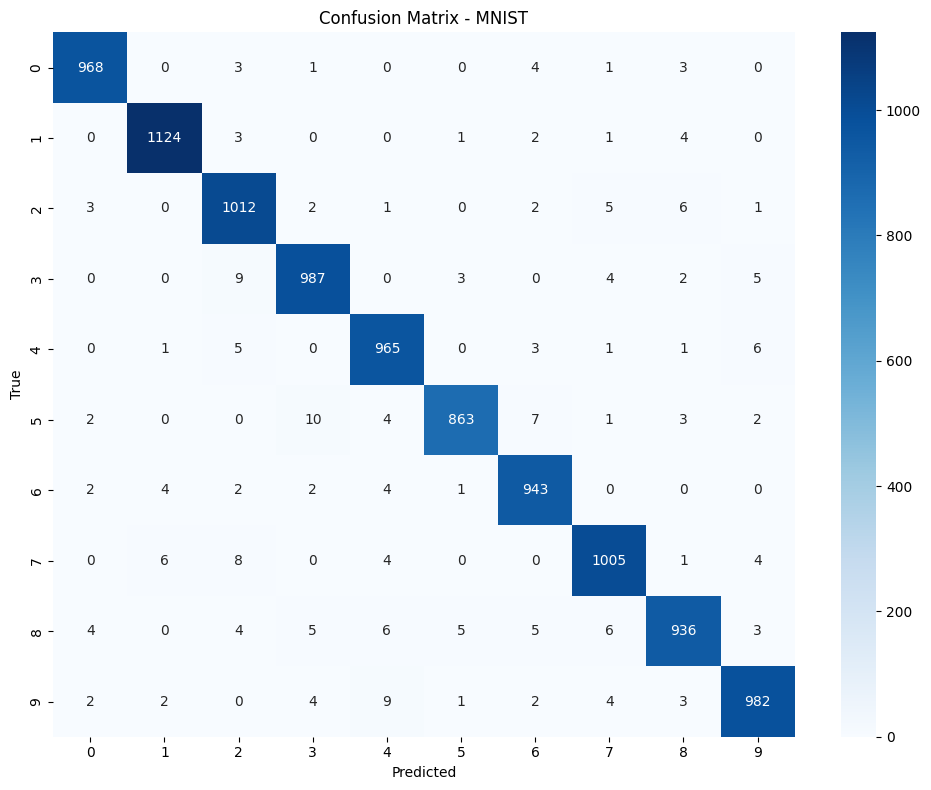

In [7]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import time

# Set seeds for reproducibility
tf.random.set_seed(0)
np.random.seed(0)

# ============================================
# PROBLEM 5: MNIST Classification (FULLY FIXED)
# ============================================

# Check available devices
print("Available physical devices:", tf.config.list_physical_devices())

# Load MNIST
print("\nLoading MNIST dataset...")
mnist = tf.keras.datasets.mnist
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()

# Preprocess images
X_train_full = X_train_full.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# Reshape to 784 features
X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

# CRITICAL FIX: Convert labels to int32 immediately
y_train_full = y_train_full.astype(np.int32)
y_test = y_test.astype(np.int32)

print(f"X_train shape: {X_train_full.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_full.shape}, y_test shape: {y_test.shape}")
print(f"y_train dtype: {y_train_full.dtype}, y_test dtype: {y_test.dtype}")

# Split training into train and validation (90/10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=0, stratify=y_train_full
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"y_train dtype: {y_train.dtype}, y_val dtype: {y_val.dtype}")

# Create dataset with explicit type casting
train_dataset = tf.data.Dataset.from_tensor_slices((
    X_train,
    tf.cast(y_train, tf.int32)  # Explicitly cast to int32
))
train_dataset = train_dataset.shuffle(len(X_train), seed=0, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size=128)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Also create validation and test datasets for consistent typing
val_dataset = tf.data.Dataset.from_tensor_slices((
    X_val,
    tf.cast(y_val, tf.int32)
)).batch(128)

test_dataset = tf.data.Dataset.from_tensor_slices((
    X_test,
    tf.cast(y_test, tf.int32)
)).batch(128)

# MNIST Model
class MNISTNetwork(tf.Module):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_classes, seed=0):
        super().__init__()
        generator = tf.random.Generator.from_seed(seed)
        # Xavier/Glorot initialization
        self.w1 = tf.Variable(generator.normal((n_input, n_hidden1), stddev=np.sqrt(1.0/n_input)))
        self.b1 = tf.Variable(tf.zeros((n_hidden1,)))
        self.w2 = tf.Variable(generator.normal((n_hidden1, n_hidden2), stddev=np.sqrt(1.0/n_hidden1)))
        self.b2 = tf.Variable(tf.zeros((n_hidden2,)))
        self.w3 = tf.Variable(generator.normal((n_hidden2, n_classes), stddev=np.sqrt(1.0/n_hidden2)))
        self.b3 = tf.Variable(tf.zeros((n_classes,)))

    def __call__(self, x):
        layer_1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        layer_2 = tf.nn.relu(tf.matmul(layer_1, self.w2) + self.b2)
        return tf.matmul(layer_2, self.w3) + self.b3

# Hyperparameters
learning_rate = 0.001
n_hidden1 = 128
n_hidden2 = 64
n_input = 784
n_classes = 10
num_epochs = 30
patience = 5

# Initialize model
print("\nInitializing model...")
model = MNISTNetwork(n_input, n_hidden1, n_hidden2, n_classes)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# FIXED: Accuracy function with proper type handling
def accuracy_fn(y_true, logits):
    # Ensure both are int32
    y_true = tf.cast(y_true, tf.int32)
    predictions = tf.cast(tf.argmax(logits, axis=1), tf.int32)
    correct = tf.cast(tf.equal(y_true, predictions), tf.float32)
    return tf.reduce_mean(correct)

# Training step
def train_step(X_batch, y_batch):
    # Ensure y_batch is int32
    y_batch = tf.cast(y_batch, tf.int32)

    with tf.GradientTape() as tape:
        logits = model(X_batch)
        loss = loss_fn(y_batch, logits)

    gradients = tape.gradient(loss, model.trainable_variables)
    # Clip gradients
    gradients, _ = tf.clip_by_global_norm(gradients, clip_norm=1.0)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss, accuracy_fn(y_batch, logits)

# Training
print("\nTraining MNIST Model...")
print("="*60)
start_time = time.time()

best_val_acc = 0
early_stop_counter = 0

for epoch in range(num_epochs):
    epoch_start = time.time()
    train_losses = []
    train_accuracies = []

    # Training
    for X_batch, y_batch in train_dataset:
        loss, acc = train_step(X_batch, y_batch)
        train_losses.append(float(loss))
        train_accuracies.append(float(acc))

    # Validation - using dataset for consistency
    val_losses = []
    val_accuracies = []
    for X_batch, y_batch in val_dataset:
        val_logits = model(X_batch)
        val_loss = loss_fn(y_batch, val_logits)
        val_acc = accuracy_fn(y_batch, val_logits)
        val_losses.append(float(val_loss))
        val_accuracies.append(float(val_acc))

    avg_val_loss = np.mean(val_losses)
    avg_val_acc = np.mean(val_accuracies)

    epoch_time = time.time() - epoch_start

    # Early stopping
    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        best_weights = [w.numpy() for w in model.trainable_variables]
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if epoch % 5 == 0 or epoch == num_epochs - 1:
        print(f"Epoch {epoch:3d}/{num_epochs-1} ({epoch_time:.1f}s), "
              f"loss: {np.mean(train_losses):.4f}, "
              f"train_acc: {np.mean(train_accuracies):.4f}, "
              f"val_loss: {avg_val_loss:.4f}, val_acc: {avg_val_acc:.4f}")

    if early_stop_counter >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nTotal training time: {time.time() - start_time:.2f} seconds")
print("="*60)

# Restore best weights
for var, weight in zip(model.trainable_variables, best_weights):
    var.assign(weight)

# Test evaluation
print("\nEvaluating on test set...")
test_losses = []
test_accuracies = []

for X_batch, y_batch in test_dataset:
    test_logits = model(X_batch)
    test_loss = loss_fn(y_batch, test_logits)
    test_acc = accuracy_fn(y_batch, test_logits)
    test_losses.append(float(test_loss))
    test_accuracies.append(float(test_acc))

test_accuracy = np.mean(test_accuracies)
test_loss = np.mean(test_losses)

print(f"\n{'='*60}")
print(f"TEST RESULTS:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"{'='*60}")

# Show sample predictions
print(f"\nSample predictions (first 10 test images):")
# Get first batch from test dataset
for X_batch, y_batch in test_dataset.take(1):
    test_logits = model(X_batch)
    test_predictions = tf.argmax(test_logits, axis=1)

    for i in range(10):
        pred = test_predictions[i].numpy()
        true = y_batch[i].numpy()
        status = "✓" if pred == true else "✗"
        print(f"Sample {i}: Predicted={pred}, True={true} {status}")

# Optional: Visualize confusion matrix
try:
    from sklearn.metrics import confusion_matrix
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Get all predictions
    all_preds = []
    all_labels = []
    for X_batch, y_batch in test_dataset:
        test_logits = model(X_batch)
        preds = tf.argmax(test_logits, axis=1).numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - MNIST')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig('mnist_confusion_matrix.png', dpi=100)
    print("\n✓ Confusion matrix saved as 'mnist_confusion_matrix.png'")
except Exception as e:
    print(f"\nCould not create confusion matrix: {e}")